## Resume Screening and Candidate Selection Model

### 1. Business Problem


Recruiters receive a large number of resumes for each job, making manual screening slow, inconsistent, and error-prone. An automated system is needed to quickly filter resumes, identify suitable candidates, and improve hiring efficiency.

### 2. Project Goal

Build a Machine Learning model that:

It takes resume data as input Analyzes skills, experience, keywords Predicts whether a candidate should be shortlisted or not

Output: 1 then Selected 0 then Rejected

### Import libraries

In [442]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

### load dataset

In [443]:
df = pd.read_csv(r"C:\Users\VARSHA SURA\Downloads\resume_dataset_1000.csv")
df.head()

,age,education_level,cgpa,internships,projects,experience_years,skills_score,soft_skills_score,certifications,hackathons,research_papers,company_type,hired
0,28,Masters,6.95,0,1,5.54,21,5.40,0,3,1,MNC,0
1,25,Bachelors,9.48,2,7,5.85,12,7.84,4,2,1,MNC,1
2,34,Bachelors,7.29,1,0,5.00,19,5.41,3,0,0,MNC,0
3,32,Masters,6.83,3,5,1.82,19,8.28,2,2,0,Mid-size,1
4,29,Bachelors,7.82,3,5,5.80,12,9.24,3,3,0,Mid-size,0


In [444]:
df.duplicated().sum()

np.int64(0)

In [445]:
df.isnull().sum()

age                  0
education_level      0
cgpa                 0
internships          0
projects             0
experience_years     0
skills_score         0
soft_skills_score    0
certifications       0
hackathons           0
research_papers      0
company_type         0
hired                0
dtype: int64

In [446]:
df['hired'].value_counts()

hired
1    673
0    327
Name: count, dtype: int64

In [447]:
df.shape

(1000, 13)

In [448]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   education_level    1000 non-null   object 
 2   cgpa               1000 non-null   float64
 3   internships        1000 non-null   int64  
 4   projects           1000 non-null   int64  
 5   experience_years   1000 non-null   float64
 6   skills_score       1000 non-null   int64  
 7   soft_skills_score  1000 non-null   float64
 8   certifications     1000 non-null   int64  
 9   hackathons         1000 non-null   int64  
 10  research_papers    1000 non-null   int64  
 11  company_type       1000 non-null   object 
 12  hired              1000 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 101.7+ KB


### data preprocessing

In [450]:
df['company_type'].unique()

array(['MNC', 'Mid-size', 'Startup'], dtype=object)

In [451]:
df['education_level'].unique()

array(['Masters', 'Bachelors'], dtype=object)

In [453]:
encoder = OrdinalEncoder(categories=[['Startup', 'Mid-size','MNC']])
df['company_type'] = encoder.fit_transform(df[['company_type']])

In [454]:
encoder = OrdinalEncoder(categories=[['Bachelors', 'Masters', 'PhD']])
df['education_level'] = encoder.fit_transform(df[['education_level']])

In [455]:
df['education_level']=df['education_level'].astype('int')

In [456]:
df['company_type']=df['company_type'].astype('int')

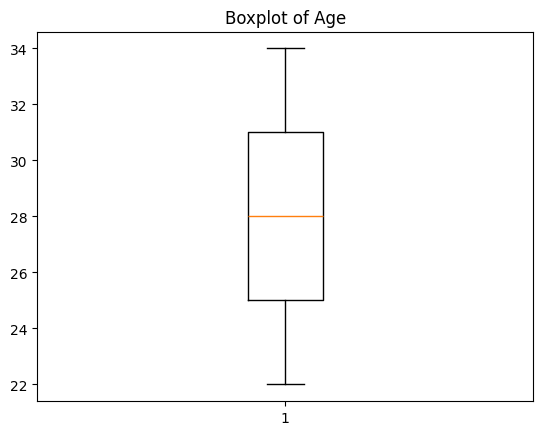

In [457]:
import matplotlib.pyplot as plt
plt.boxplot(df['age'])
plt.title("Boxplot of Age")
plt.show()

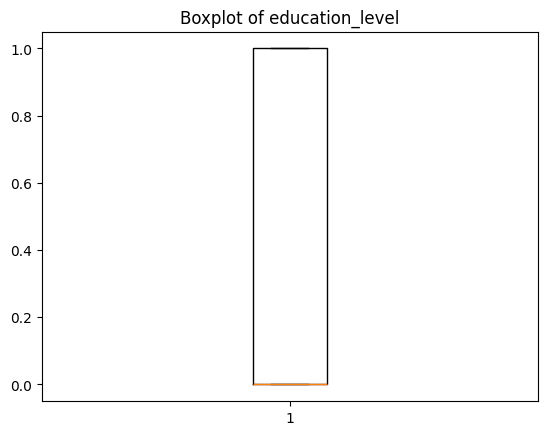

In [458]:
plt.boxplot(df['education_level'])
plt.title("Boxplot of education_level")
plt.show()

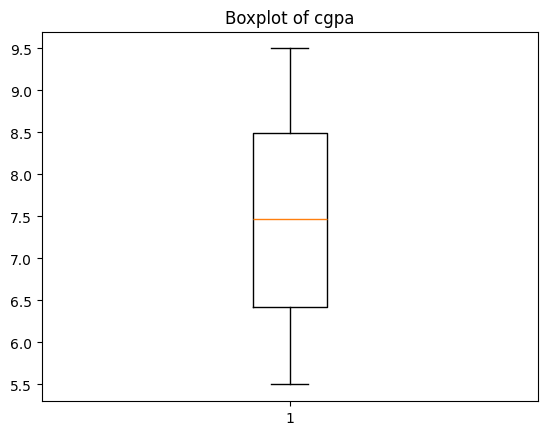

In [459]:
plt.boxplot(df['cgpa'])
plt.title("Boxplot of cgpa")
plt.show()

In [460]:
df['cgpa'].unique()

array([6.95, 9.48, 7.29, 6.83, 7.82, 5.86, 9.35, 8.04, 8.52, 6.18, 7.14,
       7.19, 8.79, 5.5 , 6.7 , 9.42, 7.4 , 7.03, 5.98, 9.4 , 5.58, 8.45,
       8.57, 6.47, 8.19, 5.87, 6.53, 8.65, 8.96, 7.93, 7.53, 6.14, 5.75,
       5.97, 6.41, 6.87, 7.02, 6.89, 6.46, 7.54, 8.8 , 6.62, 9.27, 8.99,
       6.15, 7.8 , 7.77, 7.06, 7.5 , 7.09, 7.66, 8.01, 8.2 , 7.63, 8.39,
       6.07, 6.35, 8.77, 6.79, 5.59, 6.12, 6.39, 9.33, 7.79, 9.23, 7.42,
       6.75, 6.06, 9.09, 8.82, 6.77, 9.31, 8.17, 5.99, 7.41, 7.52, 6.43,
       5.82, 8.61, 7.88, 9.25, 9.  , 6.61, 8.91, 5.57, 7.91, 6.96, 7.05,
       7.76, 6.27, 7.44, 7.98, 6.69, 7.22, 5.8 , 8.63, 6.56, 6.21, 8.27,
       7.97, 8.03, 6.42, 6.38, 6.2 , 8.12, 8.89, 8.4 , 8.67, 7.12, 6.92,
       7.6 , 7.43, 9.36, 6.49, 6.04, 7.17, 8.66, 7.83, 8.22, 6.26, 8.84,
       8.02, 6.3 , 5.76, 5.67, 6.99, 8.08, 6.1 , 6.01, 8.11, 8.74, 7.96,
       8.94, 7.07, 9.32, 6.03, 5.91, 8.13, 5.81, 9.22, 6.51, 8.62, 7.48,
       7.3 , 9.06, 9.03, 5.92, 9.45, 7.27, 5.69, 5.

In [461]:
df['cgpa'] = df['cgpa'].apply(lambda x: 10 if x > 10 else x)

In [462]:
df['cgpa'].unique()

array([6.95, 9.48, 7.29, 6.83, 7.82, 5.86, 9.35, 8.04, 8.52, 6.18, 7.14,
       7.19, 8.79, 5.5 , 6.7 , 9.42, 7.4 , 7.03, 5.98, 9.4 , 5.58, 8.45,
       8.57, 6.47, 8.19, 5.87, 6.53, 8.65, 8.96, 7.93, 7.53, 6.14, 5.75,
       5.97, 6.41, 6.87, 7.02, 6.89, 6.46, 7.54, 8.8 , 6.62, 9.27, 8.99,
       6.15, 7.8 , 7.77, 7.06, 7.5 , 7.09, 7.66, 8.01, 8.2 , 7.63, 8.39,
       6.07, 6.35, 8.77, 6.79, 5.59, 6.12, 6.39, 9.33, 7.79, 9.23, 7.42,
       6.75, 6.06, 9.09, 8.82, 6.77, 9.31, 8.17, 5.99, 7.41, 7.52, 6.43,
       5.82, 8.61, 7.88, 9.25, 9.  , 6.61, 8.91, 5.57, 7.91, 6.96, 7.05,
       7.76, 6.27, 7.44, 7.98, 6.69, 7.22, 5.8 , 8.63, 6.56, 6.21, 8.27,
       7.97, 8.03, 6.42, 6.38, 6.2 , 8.12, 8.89, 8.4 , 8.67, 7.12, 6.92,
       7.6 , 7.43, 9.36, 6.49, 6.04, 7.17, 8.66, 7.83, 8.22, 6.26, 8.84,
       8.02, 6.3 , 5.76, 5.67, 6.99, 8.08, 6.1 , 6.01, 8.11, 8.74, 7.96,
       8.94, 7.07, 9.32, 6.03, 5.91, 8.13, 5.81, 9.22, 6.51, 8.62, 7.48,
       7.3 , 9.06, 9.03, 5.92, 9.45, 7.27, 5.69, 5.

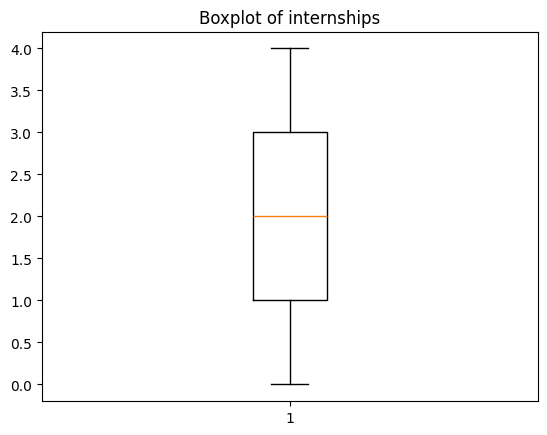

In [463]:
plt.boxplot(df['internships'])
plt.title("Boxplot of internships")
plt.show()

In [464]:
df['internships'].unique()

array([0, 2, 1, 3, 4])

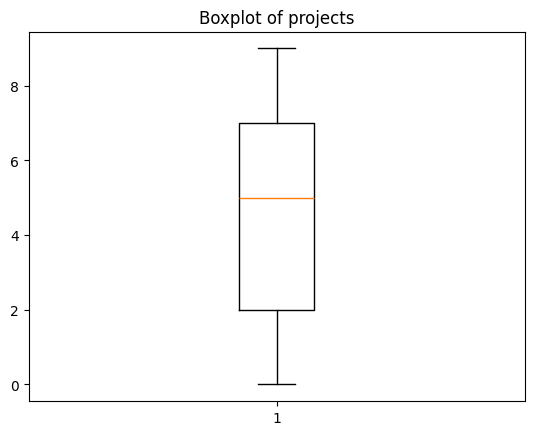

In [465]:
plt.boxplot(df['projects'])
plt.title("Boxplot of projects")
plt.show()

In [466]:
df['projects'].unique()

array([1, 7, 0, 5, 3, 9, 2, 4, 6, 8])

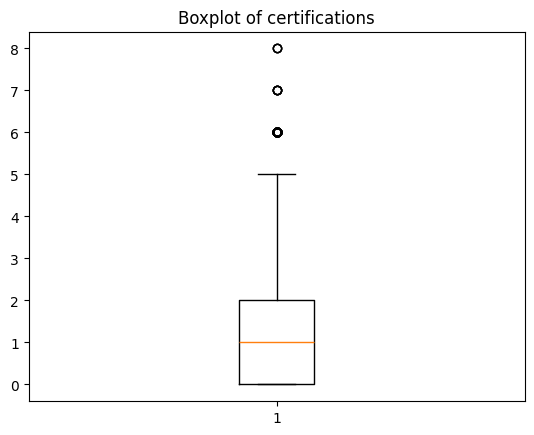

In [365]:
plt.boxplot(df['certifications'])
plt.title("Boxplot of certifications")
plt.show()

In [468]:
df['certifications'].unique()

array([0, 4, 3, 2, 1])

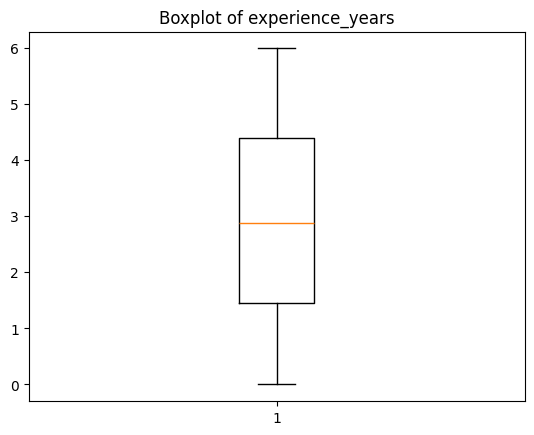

In [469]:
plt.boxplot(df['experience_years'])
plt.title("Boxplot of experience_years")
plt.show()

In [470]:
df['experience_years'].unique()

array([5.54, 5.85, 5.  , 1.82, 5.8 , 3.77, 5.58, 4.06, 1.84, 2.22, 3.3 ,
       4.74, 1.91, 3.48, 2.07, 4.89, 2.8 , 0.46, 1.  , 0.37, 3.  , 0.64,
       0.68, 5.65, 5.24, 2.71, 5.91, 0.  , 3.68, 3.7 , 2.74, 2.38, 2.73,
       2.49, 4.38, 0.81, 1.19, 1.08, 1.57, 3.15, 0.67, 5.21, 1.78, 0.98,
       4.05, 0.23, 3.72, 4.19, 1.29, 0.25, 2.18, 0.59, 0.7 , 1.53, 1.77,
       3.18, 4.07, 3.56, 0.89, 1.03, 5.27, 3.35, 5.22, 2.23, 3.69, 3.14,
       2.82, 3.01, 1.2 , 1.89, 4.75, 5.49, 2.16, 1.17, 1.94, 5.93, 1.95,
       2.36, 3.62, 4.81, 2.54, 5.97, 0.06, 5.37, 4.72, 3.71, 2.05, 0.08,
       1.36, 3.4 , 2.11, 3.66, 0.14, 0.76, 1.14, 2.76, 4.51, 5.43, 5.01,
       1.18, 2.65, 1.59, 3.02, 0.41, 1.31, 5.61, 2.67, 0.09, 1.48, 5.2 ,
       0.99, 2.87, 0.13, 4.92, 4.95, 4.73, 1.7 , 5.02, 3.26, 2.24, 3.75,
       0.07, 0.86, 4.45, 1.46, 3.59, 2.31, 5.13, 5.71, 5.3 , 1.62, 1.16,
       2.85, 0.04, 0.15, 3.32, 3.12, 1.21, 1.55, 5.51, 4.67, 4.93, 5.42,
       1.98, 3.54, 5.62, 5.9 , 4.78, 4.54, 4.08, 0.

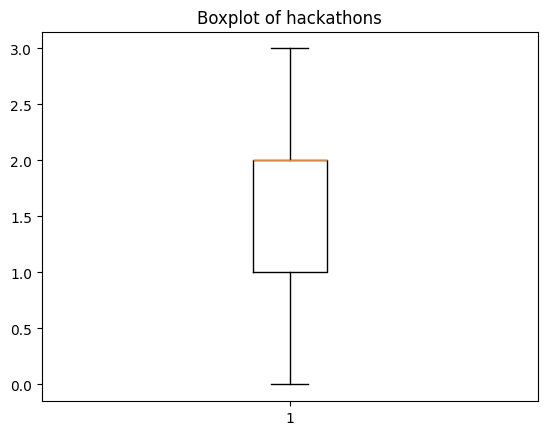

In [471]:

plt.boxplot(df['hackathons'])
plt.title("Boxplot of hackathons")
plt.show()

In [472]:
df['hackathons'].unique()

array([3, 2, 0, 1])

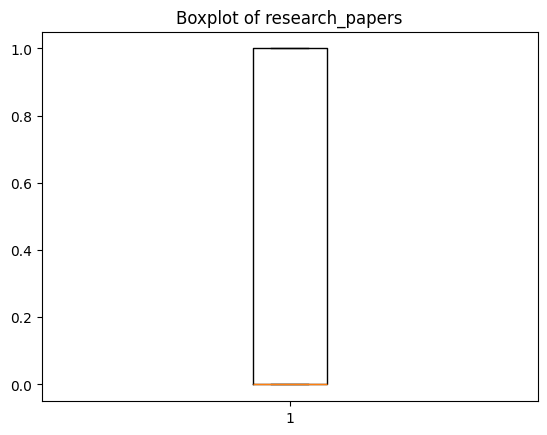

In [473]:
plt.boxplot(df['research_papers'])
plt.title("Boxplot of research_papers")
plt.show()

In [474]:
df['research_papers'].unique()

array([1, 0])

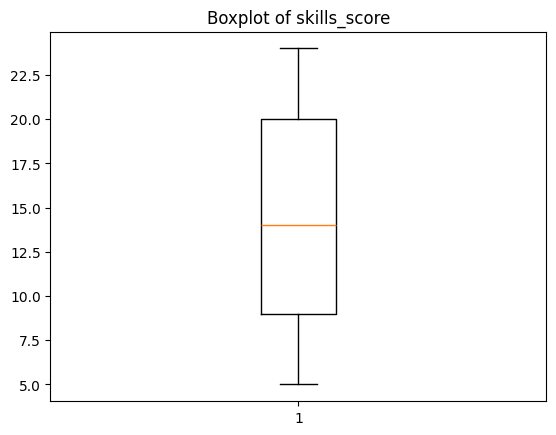

In [475]:
plt.boxplot(df['skills_score'])
plt.title("Boxplot of skills_score")
plt.show()

In [476]:
df['skills_score'].unique()

array([21, 12, 19, 20, 23, 15,  6, 17,  8, 16,  7, 22, 24,  9, 18, 11, 14,
       13, 10,  5])

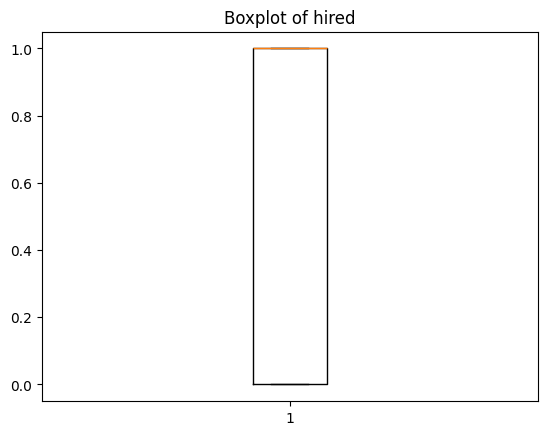

In [477]:
plt.boxplot(df['hired'])
plt.title("Boxplot of hired")
plt.show()

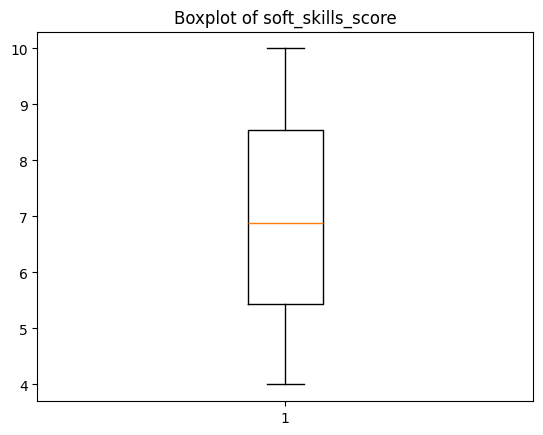

In [478]:
plt.boxplot(df['soft_skills_score'])
plt.title("Boxplot of soft_skills_score")
plt.show()

In [378]:
df['resume_length_words'].unique()

array([409, 237, 435, 340, 371, 345, 571, 443, 414, 455, 386, 321, 431,
       294, 499, 297, 308, 633, 505, 163, 477, 607, 614, 496, 635, 685,
       436, 539, 290, 556, 535, 449, 577, 569, 338, 474, 413, 599, 684,
       595, 339, 403, 398, 582, 336, 364, 472, 676, 626, 513, 347, 501,
       573, 610, 616, 625, 557, 510, 531, 634, 532, 362, 547, 314, 453,
       315, 586, 507, 561, 523, 408, 517, 471, 437, 416, 385, 503, 389,
       512, 534, 704, 541, 266, 590, 508, 613, 522, 456, 473, 470, 447,
       583, 552, 446, 422, 372, 332, 528, 480, 509, 671, 272, 788, 441,
       481, 360, 254, 574, 650, 368, 629, 636, 502, 511, 375, 490, 514,
       334, 406, 402, 466, 246, 489, 619, 179, 426, 293, 384, 281, 419,
       353, 451, 367, 465, 581, 594, 442, 232, 369,  77, 301, 394, 275,
       500, 601, 170, 759, 747, 592, 423, 433, 352, 184, 395, 494, 678,
       478, 412, 565, 196, 450, 357, 391, 104, 484, 382, 427, 568, 632,
       212, 231, 392, 559, 461, 288, 383, 355, 459, 289, 192, 35

In [480]:
df['age'].skew()

np.float64(0.006142144260851907)

In [481]:
df['education_level'].skew()

np.float64(0.8483488742697008)

In [482]:
df['cgpa'].skew()

np.float64(0.007726256015377839)

In [483]:
df['internships'].skew()

np.float64(0.010854207742605353)

In [484]:
df['projects'].skew()

np.float64(-0.02099244410267867)

In [485]:
df['certifications'].skew()

np.float64(0.07021547722840082)

In [486]:
df['experience_years'].skew()

np.float64(0.038493186932270475)

In [487]:
df['hackathons'].skew()

np.float64(-0.007663228976306336)

In [488]:
df['research_papers'].skew()

np.float64(0.036059945889648365)

In [489]:
df['skills_score'].skew()

np.float64(0.033941185423139356)

In [490]:
df['hired'].value_counts()

hired
1    673
0    327
Name: count, dtype: int64

In [491]:
df['hired'].value_counts(normalize=True)

hired
1    0.673
0    0.327
Name: proportion, dtype: float64

In [492]:
df['hired'].unique()

array([0, 1])

In [493]:
from imblearn.over_sampling import SMOTE
X = df.drop('hired', axis=1)
y = df['hired']
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [494]:
df['soft_skills_score'].skew()

np.float64(0.06934186227184867)

## train and test

In [495]:
X = df.drop('hired', axis=1)
y = df['hired']

In [496]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)


### Train Models

In [497]:
## Logistic Regression
model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train, y_train)
y_predlr = model.predict(X_test)

In [498]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [499]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100,class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [500]:
# knn
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=5)
kn.fit(X_train, y_train)
y_pred_kn=kn.predict(X_test)

In [501]:
print("Logistic Regression:", accuracy_score(y_test, y_predlr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_kn))


Logistic Regression: 0.724
Decision Tree: 0.864
Random Forest: 0.884
KNN: 0.756


In [507]:
print("random forest Report:\n")
print(classification_report(y_test, y_pred_rf))

random forest Report:

              precision    recall  f1-score   support

           0       0.90      0.73      0.81        82
           1       0.88      0.96      0.92       168

    accuracy                           0.88       250
   macro avg       0.89      0.85      0.86       250
weighted avg       0.88      0.88      0.88       250



In [504]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [509]:
from xgboost import XGBClassifier

In [510]:
model=XGBClassifier()
model.fit(X_train_res,y_train_res)
ypred=model.predict(X_test)
print('claassification report',classification_report(y_test,ypred))

claassification report               precision    recall  f1-score   support

           0       0.87      0.82      0.84        82
           1       0.91      0.94      0.93       168

    accuracy                           0.90       250
   macro avg       0.89      0.88      0.88       250
weighted avg       0.90      0.90      0.90       250



In [511]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(y_res.value_counts())

hired
1    505
0    505
Name: count, dtype: int64


In [514]:
from sklearn.metrics import accuracy_score

# predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.9


In [515]:
import pickle
best_model = model

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [516]:
import os
print(os.getcwd())

C:\Users\VARSHA SURA
